CACHE_SIZE = 0
EXPERIMENT_ID = 2
ALGORITHM_ID = 1
POPULATION_SIZE = 60
TERMINATE_GENERATION = None
TERMINATE_EVALUATION = 300
VERBOSE = True
RAND_SEED = 2020
IS_PROBABILITY_DONT_CARE = False
ANTECEDENT_NUMBER_DO_NOT_DONT_CARE = 5
DONT_CARE_RT = 0.8
INITIATION_RULE_NUM = 30
MAX_NUM_RULES = 60
MIN_NUM_RULES = 1
ANTECEDENT_FACTORY = heuristic-antecedent-factory
CROSSOVER_TYPE = hybrid-gbml-crossover
HYBRID_CROSS_RT = 1
MICHIGAN_OPE_RT = 0.5
RULE_CHANGE_RT = 0.2
MICHIGAN_CROSS_RT = 0.9
PITTSBURGH_CROSS_RT = 0.9
OBJECTIVES = ['num-rules', 'error-rate']
ROOT_FOLDER = results
IS_MULTI_LABEL = False
TRAIN_FILE = ../dataset/iris/a0_1_iris-10tra.dat
TEST_FILE = ../dataset/iris/a0_1_iris-10tst.dat
DATA_NAME = iris
GEN_PLOT = False
NO_OUTPUT_FILES = True
PRETTY_XML = False
OFFSPRING_POPULATION_SIZE = 60
ALGORITHM_ID_DIR = results\1
EXPERIMENT_ID_DIR = results\1\iris\2
DATA_SIZE = 135
ATTRIBUTE_NUMBER = 4
CLASS_LABEL_NUMBER = 3
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |    

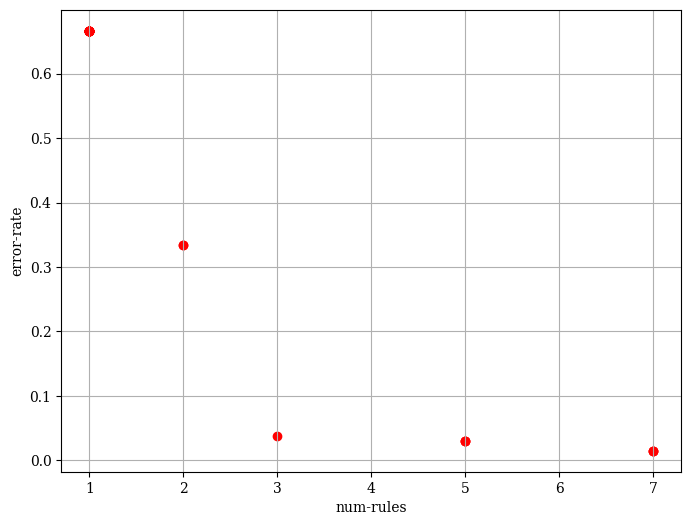

In [3]:
from mofgbmlpy.fuzzy.knowledge.factory.homo_triangle_knowledge_factory_2_3_4_5 import \
    HomoTriangleKnowledgeFactory_2_3_4_5
from mofgbmlpy.main.nsgaii.mofgbml_nsgaii_main import MoFGBMLNSGAIIMain

if __name__ == '__main__':
    runner = MoFGBMLNSGAIIMain(HomoTriangleKnowledgeFactory_2_3_4_5)
    import os
    os.chdir("C:/Users/Ayato Tomofuji/Documents/Mof/MoFGBMLPy/examples")
    args = [
        "--algorithm-id", "1",
        "--experiment-id", "2",
        "--data-name", "iris",
        "--train-file", "../dataset/iris/a0_1_iris-10tra.dat",
        "--test-file", "../dataset/iris/a0_1_iris-10tst.dat",
        "--terminate-evaluation", "300",
        "--objectives", "num-rules", "error-rate",
        # "--crossover-type", "pittsburgh-crossover",
        # "--antecedent-factory", "all-combination-antecedent-factory",
        "--no-output-files",
        "--verbose",
    ]
    #runner.main(sys.argv[1:])
    results = runner.main(args)



    i = 1
    for var in results.opt.get("X")[0, 0].get_vars():
        print(f"{i}:\t{var.get_rule().get_linguistic_representation()}")
        i += 1

    plot = runner.get_pareto_front_plot(results.opt)
    plot.show()
    # plot.ax.set_ylim([0,1])
    plot.ax.grid(visible=True)
    results.opt.get('X')[1, 0]



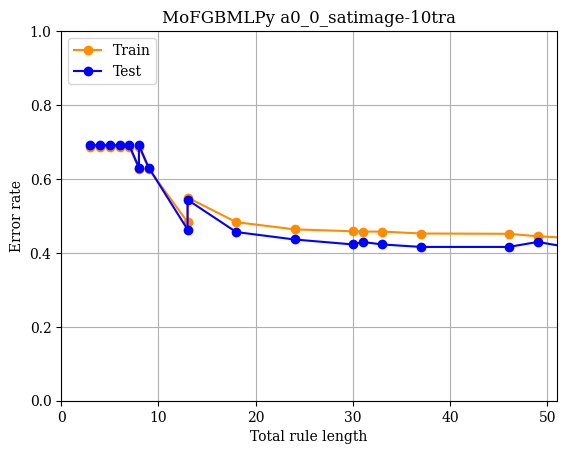

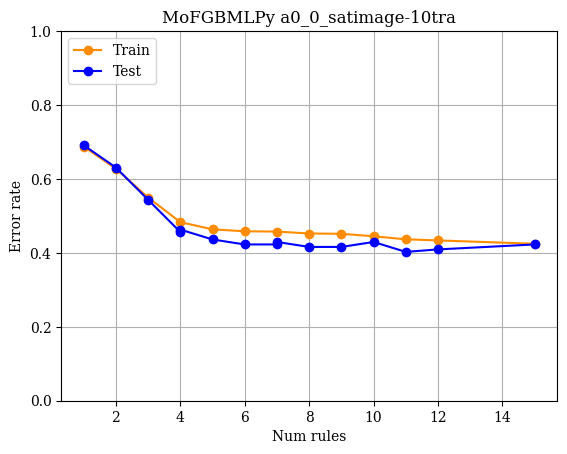


識別器 1 のルール:
  ルール 1: IF	       x0 IS low_2 AND x1 IS low_medium_4 AND x2 IS high_2 AND x3 IS low_2 AND x4 IS low_3 AND x7 IS very_low_5 THEN Class is  2 with RW: 0.0837 RW: 0.0837

識別器 2 のルール:
  ルール 1: IF	       x0 IS high_2 AND x1 IS medium_5 AND x2 IS high_2 AND x3 IS high_medium_4 AND x4 IS low_3 AND x6 IS high_medium_4 THEN Class is  0 with RW: 0.4813 RW: 0.4813
  ルール 2: IF	        x0 IS low_5 AND x1 IS low_medium_4 AND x2 IS medium_5 AND x3 IS low_medium_4 AND x5 IS very_low_5 AND x6 IS high_2 AND x7 IS low_4 THEN Class is  2 with RW: 0.0714 RW: 0.0714
  ルール 3: IF	       x0 IS high_3 AND x1 IS high_5 AND x2 IS low_3 AND x4 IS low_2 AND x6 IS high_medium_4 AND x7 IS medium_3 THEN Class is  3 with RW: 0.1542 RW: 0.1542
  ルール 4: IF	       x0 IS low_medium_4 AND x1 IS low_medium_4 AND x2 IS very_low_5 AND x5 IS very_low_5 AND x6 IS high_3 AND x7 IS high_2 THEN Class is  5 with RW: 0.8070 RW: 0.8070
  ルール 5: IF	       x0 IS low_2 AND x2 IS medium_5 AND x3 IS low_3 AND x5 IS low_2 AND 

In [7]:
    runner.plot_line_interpretability_error_rate_tradeoff(results.opt.get('X')[:, 0],
                                                          title="MoFGBMLPy a0_0_satimage-10tra", xlim=[0, 51])
    runner.plot_line_interpretability_error_rate_tradeoff(results.opt.get('X')[:, 0],
                                                          title="MoFGBMLPy a0_0_satimage-10tra", x_key='num_rules')

    
    for idx, sol in enumerate(results.opt.get("X")[:, 0]):
        print(f"\n識別器 {idx + 1} のルール:")

        # 各識別器のルールを取得し表示
        for rule_idx, var in enumerate(sol.get_vars(), start=1):
            print(f"  ルール {rule_idx}: {var.get_rule().get_linguistic_representation()}")
